In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score,recall_score, f1_score, roc_auc_score


In [2]:
df = pd.read_excel(r"C:\Users\USER\Downloads\__דטאסט של מאמר 2 -עיבוד תכונות.xlsx")

df.head()


,Followers,Following,Following/Followers,Posts,Posts/(Following/Followers),Mutual Friends,Bio,Profile Picture,External Link,Threads,Labels,Labels.1,Threads.1,Profile Picture.1,External Link.1,Bio.1
0,2,2757,1378.500000,0,0.000000,0,0,0,0,0,2,Bot,N,N,N,N
1,2,505,252.500000,0,0.000000,0,0,1,0,0,3,Scam,N,Yes,N,N
2,6786,1782,0.262599,1589,6051.040404,10,1,0,1,0,0,Real,N,N,Yes,yes
3,21,1281,61.000000,0,0.000000,0,0,1,0,0,2,Bot,N,Yes,N,N
4,585,1682,2.875214,2663,926.192033,12,1,0,0,1,0,Real,Yes,N,N,yes


In [3]:
feature_order = ['Followers', 'Following', 'Following/Followers', 'Posts', 'Mutual Friends', 'Posts/(Following/Followers)', 'Bio', 'Profile Picture', 'External Link', 'Threads']
X = df[feature_order]
y = df['Labels']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

 Instagram Fake Account Detector 



Enter Followers:  5
Enter Following:  766
Enter Posts:  0
Enter Mutual Friends:  0
Does the account have Bio? (yes/no):  yes
Does the account have Profile Picture? (yes/no):  yes
Does the account have External Link? (yes/no):  yes
Does the account have Threads? (yes/no):  no



Prediction : Scam
Confidence : 75.85%

Calculating feature contributions...


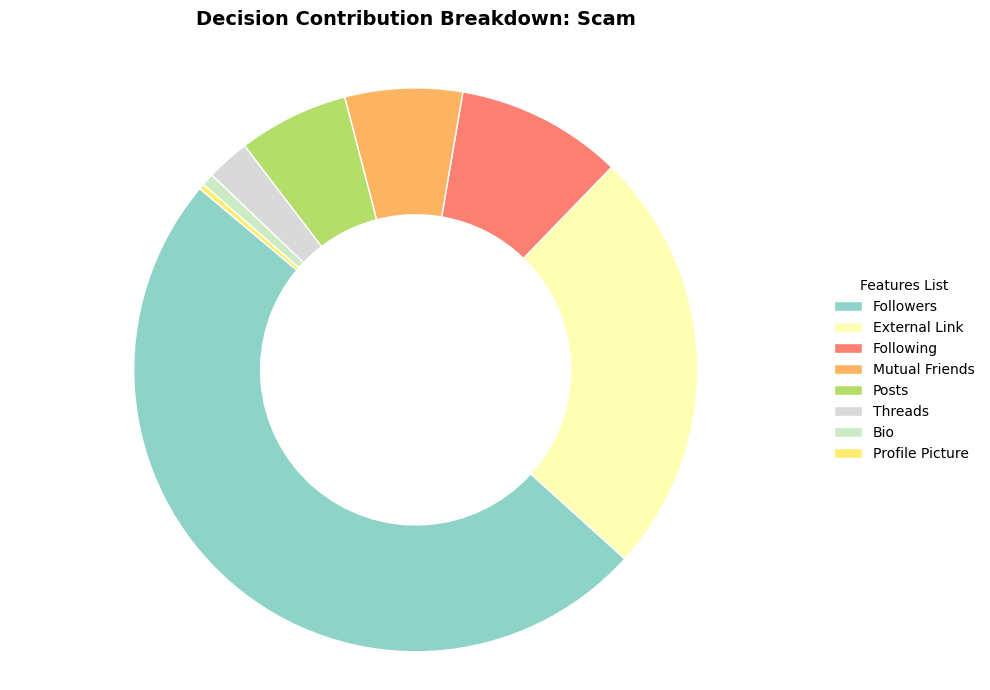


1. Most important feature: Followers (49.4%)
2. Second most important feature: External Link (24.5%)


In [12]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'random_state': 42,
    'n_jobs': -1
}

derived_features = [
    'Following/Followers',
    'Posts/(Following/Followers)'
]

feature_columns = [
    f for f in X.columns
    if f not in derived_features
]

X_train_sub = X_train[feature_columns]
model = RandomForestClassifier(**rf_params)
model.fit(X_train_sub, y_train)

explainer = shap.TreeExplainer(model)


def get_yes_no(prompt):

    while True:

        choice = input(prompt + " (yes/no): ").lower().strip()

        if choice == "yes":
            return 1

        elif choice == "no":
            return 0

        else:
            print("Please type yes or no only.")


def predict_instagram_interactive_full(
    model,
    feature_columns
):

    print("===================================")
    print(" Instagram Fake Account Detector ")
    print("===================================\n")

    data = {}
    
#שדות מספריים
    for field in [
        'Followers',
        'Following',
        'Posts',
        'Mutual Friends'
    ]:

        while True:
            try:
                data[field] = float(input(f"Enter {field}: "))
                break
            except:
                print("Please enter numbers only.")
                
# שדות של YES / NO
    for field in [
        'Bio',
        'Profile Picture',
        'External Link',
        'Threads'
    ]:

        data[field] = get_yes_no(f"Does the account have {field}?")

    input_df = pd.DataFrame([data])
    input_df = input_df[feature_columns] #שמירת העמודות באותו הסדר שהמודל התאמן עליהן 

    prediction = model.predict(input_df)[0]
    probabilities = model.predict_proba(input_df)[0] #ווקטור הסתברויות לכל אחת מן המחלקות
    confidence = np.max(probabilities) * 100 # החזרת ההסתברות הגבוה ביותר 

    labels_map = {
        0: "Real",
        1: "Spam",
        2: "Bot",
        3: "Scam"
    }

    result = labels_map[prediction] # החזרת שם המחלקה

    print("\n===================================")
    print(f"Prediction : {result}")
    print(f"Confidence : {confidence:.2f}%")
    print("===================================")

    # SHAP Analysis (כפי שביקשת)
    print("\nCalculating feature contributions...")

    shap_values = explainer.shap_values(input_df) #כמה כל פיצ'ר תרם לתחזית

    # טיפול בגרסאות שונות של SHAP
    if isinstance(shap_values, list):
        current_values = shap_values[1][0]
    else:
        if len(np.array(shap_values).shape) == 3:
            current_values = shap_values[0, :, 1]
        else:
            current_values = shap_values[0]

    feature_impact = pd.Series(
        np.abs(current_values),
        index=feature_columns
    ).sort_values(ascending=False)

    #יצירת גרף עוגה
    if not feature_impact.empty:

        colors = plt.cm.Set3(
            np.linspace(0, 1, len(feature_impact))
        )

        fig, ax = plt.subplots(figsize=(10, 7))

        wedges, _ = ax.pie(
            feature_impact,
            startangle=140,
            colors=colors,
            wedgeprops=dict(width=0.45, edgecolor='w')
        )

        ax.legend(
            wedges,
            feature_impact.index,
            title="Features List",
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1),
            frameon=False
        )

        plt.title(
            f"Decision Contribution Breakdown: {result}",
            fontsize=14,
            fontweight='bold',
            pad=25
        )

        ax.axis('equal')
        plt.tight_layout()
        plt.show()

        # =====================================
        # Top features
        # =====================================

        total_impact = feature_impact.sum()

        if len(feature_impact) >= 2:

            print("\n" + "="*50)
            print(
                f"1. Most important feature: "
                f"{feature_impact.index[0]} "
                f"({(feature_impact.iloc[0]/total_impact)*100:.1f}%)"
            )

            print(
                f"2. Second most important feature: "
                f"{feature_impact.index[1]} "
                f"({(feature_impact.iloc[1]/total_impact)*100:.1f}%)"
            )
            print("="*50)

    return result, confidence

prediction, confidence = predict_instagram_interactive_full(
    model,
    feature_columns
)